<a href="https://colab.research.google.com/github/xavierjacomep/curso-intro-machine-learning/blob/main/titanic_primer_clasificador_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0F172A; padding:36px 48px;">
  <h1 style="color:#FFFFFF; font-size:2em; margin:0; font-weight:800; letter-spacing:2px;">
    🚢 MI PRIMER CLASIFICADOR EN MACHINE LEARNING
  </h1>
  <h2 style="color:#0284C7; font-size:1.1em; margin:12px 0 6px 0; font-weight:400;">
    Caso Práctico: Sobrevivientes del Titanic
  </h2>
  <div style="height:3px; background:#0284C7; width:100px; margin:14px 0;"></div>
  <p style="color:#94A3B8; font-size:0.9em; margin:0;">
    Ejercicio para principiantes · Clasificación Binaria · Proceso paso a paso
  </p>
</div>
<div style="background:#1E293B; padding:16px 48px; margin-bottom:24px;">
  <p style="color:#E2E8F0; margin:0; font-size:0.9em; line-height:1.7;">
    <strong style="color:#0284C7;">¿Qué vamos a hacer?</strong>
    Predecir si un pasajero del Titanic sobrevivió o no, a partir de sus características.<br>
    <strong style="color:#0284C7;">¿Qué aprenderás?</strong>
    Cargar datos → Limpiar → Encoding → Escalamiento → Entrenar → Evaluar con métricas y matrices → <strong style="color:#F59E0B;">Validación Cruzada</strong>.
  </p>
</div>

---
## 📦 Paso 0 — Importar librerías

> Siempre lo primero: declarar todas las herramientas que vamos a usar.

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

✅ Librerías cargadas


---
## 📂 Paso 1 — Cargar los datos

Tenemos dos archivos:
- **`train.csv`** → tiene la columna `Survived` (la respuesta). Aquí entrenamos y evaluamos.
- **`test.csv`** → NO tiene `Survived`. Es para predicciones finales.

Por ahora trabajaremos solo con `train.csv`.

In [ ]:
df = pd.read_csv('train.csv')

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print()
df.head()

Filas: 891  |  Columnas: 12



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Ver el tipo de cada columna y cuántos valores nulos tiene
print("Columna          Tipo        Nulos")
print("-" * 40)
for col in df.columns:
    nulos = df[col].isnull().sum()
    print(f"  {col:<16} {str(df[col].dtype):<12} {nulos}")

Columna          Tipo        Nulos
----------------------------------------
  PassengerId      int64        0
  Survived         int64        0
  Pclass           int64        0
  Name             object       0
  Sex              object       0
  Age              float64      177
  SibSp            int64        0
  Parch            int64        0
  Ticket           object       0
  Fare             float64      0
  Cabin            object       687
  Embarked         object       2


In [ ]:
# Distribución de la variable objetivo
print("¿Cuántos sobrevivieron?")
print(df['Survived'].value_counts())
print()
print(f"  0 = No sobrevivió  →  {(df['Survived']==0).sum()} pasajeros  ({(df['Survived']==0).mean()*100:.1f}%)")
print(f"  1 = Sobrevivió     →  {(df['Survived']==1).sum()} pasajeros  ({(df['Survived']==1).mean()*100:.1f}%)")

¿Cuántos sobrevivieron?
Survived
0    549
1    342
Name: count, dtype: int64

  0 = No sobrevivió  →  549 pasajeros  (61.6%)
  1 = Sobrevivió     →  342 pasajeros  (38.4%)


---
## 🧹 Paso 2 — Limpieza mínima

Eliminamos lo que no sirve y tratamos los valores que faltan.

**Criterio simple:**
- Columnas que son solo identificadores o texto libre → las eliminamos.
- `Cabin` tiene 77% de nulos → la eliminamos.
- `Age` tiene 20% de nulos → rellenamos con la mediana.
- `Embarked` tiene 2 nulos → rellenamos con la moda (valor más frecuente).

In [ ]:
# Eliminar columnas que no aportan información al modelo
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

print("Columnas después de eliminar:", df.columns.tolist())

Columnas después de eliminar: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
# Rellenar nulos

# Age: con la mediana (más robusta que la media ante valores extremos)
mediana_age = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_age)
print(f"Age:      nulos rellenados con mediana = {mediana_age}")

# Embarked: con la moda (el puerto más frecuente)
moda_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(moda_embarked)
print(f"Embarked: nulos rellenados con moda    = '{moda_embarked}'")

print()
print(f"Nulos restantes: {df.isnull().sum().sum()} ✅")

Age:      nulos rellenados con mediana = 28.0
Embarked: nulos rellenados con moda    = 'S'

Nulos restantes: 0 ✅


---
## 🔢 Paso 3 — Feature Encoding

Los algoritmos de ML **solo entienden números**. Debemos convertir las columnas de texto a valores numéricos.

| Columna | Tipo | Transformación |
|---|---|---|
| `Sex` | Binaria | `female` → 1, `male` → 0 |
| `Embarked` | 3 categorías | Label Encoding: S→0, C→1, Q→2 |

In [ ]:
# Sex: convertir female/male a 1/0
df['Sex'] = (df['Sex'] == 'female').astype(int)

print("Sex después del encoding:")
print(df['Sex'].value_counts().rename({1: 'female (1)', 0: 'male (0)'}))

Sex después del encoding:
Sex
male (0)      577
female (1)    314
Name: count, dtype: int64


In [ ]:
# Embarked: asignar un número a cada puerto
embarked_map = {'S': 0, 'C': 1, 'Q': 2}
df['Embarked'] = df['Embarked'].map(embarked_map)

print("Embarked después del encoding:")
print(df['Embarked'].value_counts().rename({0: 'S→0', 1: 'C→1', 2: 'Q→2'}))

print()
print("DataFrame después del encoding:")
df.head()

Embarked después del encoding:
Embarked
S→0    646
C→1    168
Q→2     77
Name: count, dtype: int64

DataFrame después del encoding:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


---
## ✂️ Paso 4 — Separar features (X) y target (y)

- **X** = las columnas que el modelo usará para aprender (las "pistas").
- **y** = la columna que queremos predecir (`Survived`).

In [ ]:
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
TARGET   = 'Survived'

X = df[FEATURES]
y = df[TARGET]

print("Features (X):", FEATURES)
print("Target    (y):", TARGET)
print()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()
X.head()

Features (X): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target    (y): Survived

X shape: (891, 7)
y shape: (891,)



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


---
## 🔀 Paso 5 — Dividir en Train y Test

Separamos los datos en dos partes:
- **Train (80%):** el modelo aprende aquí.
- **Test (20%):** lo usamos para medir qué tan bien aprendió, con datos que nunca vio.

> `stratify=y` garantiza que la proporción de clases (0 y 1) sea igual en ambas partes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}  →  {y_train.sum()} sobrevivieron ({y_train.mean()*100:.1f}%)")
print(f"X_test:  {X_test.shape}   →  {y_test.sum()} sobrevivieron  ({y_test.mean()*100:.1f}%)")
print()
print("La proporción de clases es igual en ambos conjuntos ✅")

X_train: (712, 7)  →  273 sobrevivieron (38.3%)
X_test:  (179, 7)   →  69 sobrevivieron  (38.5%)

La proporción de clases es igual en ambos conjuntos ✅


---
## ⚖️ Paso 6 — Escalamiento (StandardScaler)

Algunas variables están en escalas muy distintas:
- `Age` va de 0 a 80
- `Fare` va de 0 a 512
- `Pclass` va de 1 a 3

El escalamiento lleva todas las variables a la misma escala (media=0, std=1), para que ninguna "domine" por su magnitud.

> **Regla importante:** el scaler se ajusta (`fit`) **solo con los datos de entrenamiento**.  
> Luego se aplica (`transform`) tanto al train como al test.  
> Esto evita que el modelo "vea" información del test antes de tiempo.

In [ ]:
scaler = StandardScaler()

# fit_transform: ajusta con train Y transforma train en un solo paso
X_train_scaled = scaler.fit_transform(X_train)

# transform: solo aplica la escala ya aprendida (no ajusta de nuevo)
X_test_scaled  = scaler.transform(X_test)

# Comparar antes y después en una columna
print("Columna 'Fare' — ANTES del escalamiento:")
print(f"  Media: {X_train['Fare'].mean():.2f}  |  Std: {X_train['Fare'].std():.2f}  |  Min: {X_train['Fare'].min():.2f}  |  Max: {X_train['Fare'].max():.2f}")
print()
print("Columna 'Fare' — DESPUÉS del escalamiento:")
fare_idx = FEATURES.index('Fare')
scaled_fare = X_train_scaled[:, fare_idx]
print(f"  Media: {scaled_fare.mean():.2f}  |  Std: {scaled_fare.std():.2f}  |  Min: {scaled_fare.min():.2f}  |  Max: {scaled_fare.max():.2f}")
print()
print("✅ Escalamiento aplicado correctamente")

Columna 'Fare' — ANTES del escalamiento:
  Media: 31.82  |  Std: 48.06  |  Min: 0.00  |  Max: 512.33

Columna 'Fare' — DESPUÉS del escalamiento:
  Media: -0.00  |  Std: 1.00  |  Min: -0.66  |  Max: 10.01

✅ Escalamiento aplicado correctamente


---
## 🤖 Paso 7 — Entrenar el modelo

Usamos **Regresión Logística**: el modelo más sencillo para clasificación binaria.

A pesar del nombre, **no es regresión** — es un clasificador. Aprende una frontera lineal que separa las dos clases, y produce una probabilidad entre 0 y 1.

> Si P(Survived=1) ≥ 0.5 → predice **1 (sobrevivió)**  
> Si P(Survived=1) < 0.5 → predice **0 (no sobrevivió)**

In [ ]:
modelo = LogisticRegression(max_iter=500, random_state=42)

# El modelo ajusta sus parámetros internos usando los datos de entrenamiento
modelo.fit(X_train_scaled, y_train)

print("✅ Modelo entrenado")
print()
print("Coeficientes e interpretación vía Odds Ratio")
print("=" * 60)
print(f"  {'Variable':<14} {'Coef (β)':>10}  {'Odds Ratio (eᵝ)':>16}  Interpretación")
print("-" * 60)

for feature, coef in zip(FEATURES, modelo.coef_[0]):
    odds_ratio = np.exp(coef)
    if odds_ratio > 1:
        interp = f"x{odds_ratio:.2f} más probabilidad de sobrevivir"
    else:
        interp = f"x{odds_ratio:.2f} — reduce probabilidad de sobrevivir"
    print(f"  {feature:<14} {coef:>+10.4f}  {odds_ratio:>16.4f}  {interp}")

print()
print("  Odds Ratio > 1 → la variable aumenta las chances de sobrevivir")
print("  Odds Ratio < 1 → la variable reduce  las chances de sobrevivir")
print("  Odds Ratio = 1 → la variable no tiene efecto")
print()
print("  Ejemplo de lectura:")
print("  Si Sex tiene OR=3.6 → ser mujer multiplica por 3.6 las chances de sobrevivir")
print("  Si Pclass tiene OR=0.4 → subir una clase reduce las chances al 40%")

✅ Modelo entrenado

Coeficientes e interpretación vía Odds Ratio
  Variable         Coef (β)   Odds Ratio (eᵝ)  Interpretación
------------------------------------------------------------
  Pclass            -0.9323            0.3937  x0.39 — reduce probabilidad de sobrevivir
  Sex               +1.2691            3.5577  x3.56 más probabilidad de sobrevivir
  Age               -0.5038            0.6042  x0.60 — reduce probabilidad de sobrevivir
  SibSp             -0.2632            0.7686  x0.77 — reduce probabilidad de sobrevivir
  Parch             -0.0668            0.9354  x0.94 — reduce probabilidad de sobrevivir
  Fare              +0.1012            1.1065  x1.11 más probabilidad de sobrevivir
  Embarked          +0.2206            1.2468  x1.25 más probabilidad de sobrevivir

  Odds Ratio > 1 → la variable aumenta las chances de sobrevivir
  Odds Ratio < 1 → la variable reduce  las chances de sobrevivir
  Odds Ratio = 1 → la variable no tiene efecto

  Ejemplo de lectura:
  S

---
## 🔮 Paso 8 — Generar predicciones

Le pasamos los datos de test al modelo para que prediga.

In [ ]:
# Predicciones de clase (0 o 1)
y_pred = modelo.predict(X_test_scaled)

# Probabilidades (opcional, útil para entender la "confianza" del modelo)
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

# Mostrar primeras 10 predicciones
print("Primeras 10 predicciones:")
print("-" * 52)
print(f"  {'Real':<8} {'Predicho':<12} {'P(sobrevive)':<15} {'¿Acertó?'}")
print("-" * 52)
for real, pred, prob in zip(y_test.values[:10], y_pred[:10], y_prob[:10]):
    acierto = "✅" if real == pred else "❌"
    print(f"  {real:<8} {pred:<12} {prob:<15.3f} {acierto}")

Primeras 10 predicciones:
----------------------------------------------------
  Real     Predicho     P(sobrevive)    ¿Acertó?
----------------------------------------------------
  0        0            0.066           ✅
  0        0            0.047           ✅
  1        0            0.148           ❌
  0        0            0.035           ✅
  1        1            0.689           ✅
  1        0            0.444           ❌
  1        1            0.757           ✅
  0        0            0.328           ✅
  0        0            0.339           ✅
  0        0            0.160           ✅


---
## 📊 Paso 9 — Evaluar el modelo con métricas

Calculamos cuatro métricas fundamentales para entender qué tan bien clasificó el modelo.

---

### ¿Qué mide cada métrica?

Antes de ver los números, necesitamos entender los 4 tipos de resultados posibles:

| | El modelo predice **Sobrevivió (1)** | El modelo predice **No sobrevivió (0)** |
|---|---|---|
| **Realmente sobrevivió (1)** | ✅ Verdadero Positivo (TP) | ❌ Falso Negativo (FN) |
| **Realmente NO sobrevivió (0)** | ❌ Falso Positivo (FP) | ✅ Verdadero Negativo (TN) |

Con eso:
- **Accuracy** = (TP + TN) / Total → ¿Qué porcentaje acerté en total?
- **Precision** = TP / (TP + FP) → De los que predije como "sobrevivió", ¿cuántos realmente sobrevivieron?
- **Recall** = TP / (TP + FN) → De los que realmente sobrevivieron, ¿cuántos detecté?
- **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall) → Balance entre Precision y Recall.

In [ ]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 40)
print("  MÉTRICAS DE EVALUACIÓN")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.1f}%)")
print("=" * 40)

  MÉTRICAS DE EVALUACIÓN
  Accuracy  : 0.8045  (80.4%)
  Precision : 0.7931  (79.3%)
  Recall    : 0.6667  (66.7%)
  F1-Score  : 0.7244  (72.4%)


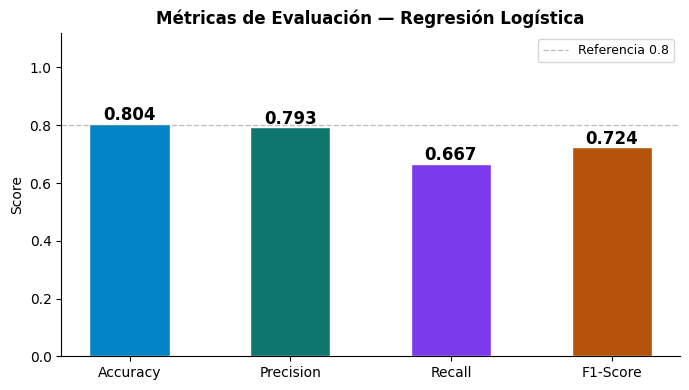

In [ ]:
# Visualizar las 4 métricas en un gráfico de barras
fig, ax = plt.subplots(figsize=(7, 4))

nombres_metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores          = [accuracy, precision, recall, f1]
colores          = ['#0284C7', '#0F766E', '#7C3AED', '#B45309']

bars = ax.bar(nombres_metricas, valores, color=colores, width=0.5, edgecolor='white')

# Etiqueta con el valor encima de cada barra
for bar, val in zip(bars, valores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f'{val:.3f}',
        ha='center', fontweight='bold', fontsize=12
    )

ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Métricas de Evaluación — Regresión Logística', fontweight='bold')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Referencia 0.8')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 📋 Paso 10 — Reporte de Clasificación

`classification_report` muestra Precision, Recall y F1 **por clase** (no solo el promedio global).  
Esto es especialmente útil cuando las clases están desbalanceadas.

In [ ]:
print("REPORTE DE CLASIFICACIÓN")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['No sobrevivió (0)', 'Sobrevivió (1)']
))

REPORTE DE CLASIFICACIÓN
                   precision    recall  f1-score   support

No sobrevivió (0)       0.81      0.89      0.85       110
   Sobrevivió (1)       0.79      0.67      0.72        69

         accuracy                           0.80       179
        macro avg       0.80      0.78      0.79       179
     weighted avg       0.80      0.80      0.80       179



In [ ]:
# ── Explicación del reporte ──────────────────────────────────────────
print("¿Cómo leer el reporte?")
print()
print("  precision  = de todos los que PREDIJE como X, ¿cuántos eran X?")
print("  recall     = de todos los que SON X en realidad, ¿cuántos detecté?")
print("  f1-score   = balance entre precision y recall")
print("  support    = cantidad real de ejemplos de esa clase en el test")
print()
print("  accuracy   = aciertos totales / total de predicciones")
print()
print("  macro avg  = promedio simple entre las dos clases")
print("  weighted avg = promedio ponderado por el support de cada clase")

¿Cómo leer el reporte?

  precision  = de todos los que PREDIJE como X, ¿cuántos eran X?
  recall     = de todos los que SON X en realidad, ¿cuántos detecté?
  f1-score   = balance entre precision y recall
  support    = cantidad real de ejemplos de esa clase en el test

  accuracy   = aciertos totales / total de predicciones

  macro avg  = promedio simple entre las dos clases
  weighted avg = promedio ponderado por el support de cada clase


---
## 🔲 Paso 11 — Matriz de Confusión

La matriz de confusión muestra, de forma visual, **cuántos aciertos y errores** cometió el modelo, y de **qué tipo** son los errores.

```
                    PREDICHO
                  0          1
REAL    0    [ TN  |  FP ]
        1    [ FN  |  TP ]
```

- **TN (Verdadero Negativo):** predijo "no sobrevivió" y era correcto.
- **TP (Verdadero Positivo):** predijo "sobrevivió" y era correcto.
- **FP (Falso Positivo):** predijo "sobrevivió" pero no sobrevivió. ← Error Tipo I
- **FN (Falso Negativo):** predijo "no sobrevivió" pero sí sobrevivió. ← Error Tipo II

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Matriz de Confusión (valores):")
print()
print("                  PREDICHO")
print("              No sobrevivió   Sobrevivió")
print(f"  REAL  No sob.  [{tn:^5}]         [{fp:^5}]")
print(f"        Sobrev.  [{fn:^5}]         [{tp:^5}]")
print()
print(f"  Verdaderos Negativos (TN): {tn}  — predijo 0, era 0  ✅")
print(f"  Verdaderos Positivos (TP): {tp}  — predijo 1, era 1  ✅")
print(f"  Falsos Positivos     (FP): {fp}   — predijo 1, era 0  ❌  (Falsa Alarma)")
print(f"  Falsos Negativos     (FN): {fn}   — predijo 0, era 1  ❌  (Caso Perdido)")

Matriz de Confusión (valores):

                  PREDICHO
              No sobrevivió   Sobrevivió
  REAL  No sob.  [ 98  ]         [ 12  ]
        Sobrev.  [ 23  ]         [ 46  ]

  Verdaderos Negativos (TN): 98  — predijo 0, era 0  ✅
  Verdaderos Positivos (TP): 46  — predijo 1, era 1  ✅
  Falsos Positivos     (FP): 12   — predijo 1, era 0  ❌  (Falsa Alarma)
  Falsos Negativos     (FN): 23   — predijo 0, era 1  ❌  (Caso Perdido)


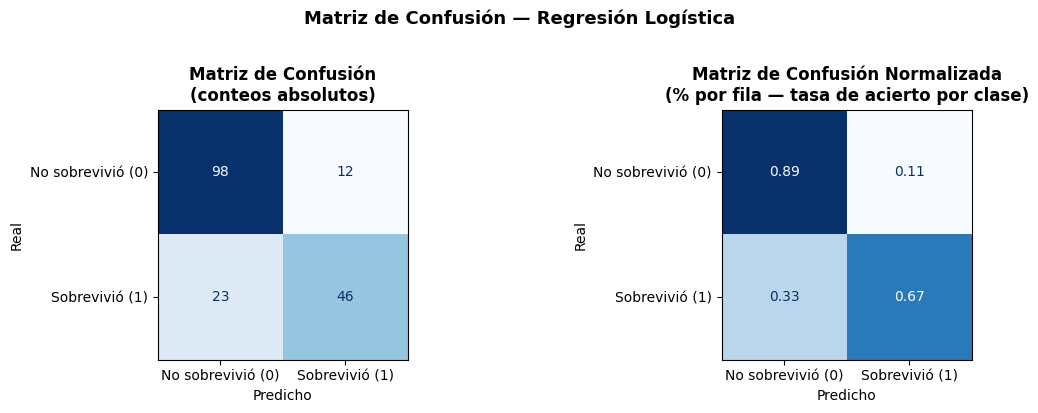


La versión normalizada muestra el % de acierto POR CLASE.
  De los que NO sobrevivieron: acertó el 89.1%
  De los que SÍ sobrevivieron: acertó el 66.7%


In [ ]:
# Visualizar la matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Gráfico 1: Conteos absolutos ──────────────────────────────────────
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No sobrevivió (0)', 'Sobrevivió (1)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión\n(conteos absolutos)', fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# ── Gráfico 2: Porcentajes (normalizada por fila) ─────────────────────
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['No sobrevivió (0)', 'Sobrevivió (1)']
)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión Normalizada\n(% por fila — tasa de acierto por clase)', fontweight='bold')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.suptitle('Matriz de Confusión — Regresión Logística', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print("La versión normalizada muestra el % de acierto POR CLASE.")
print(f"  De los que NO sobrevivieron: acertó el {cm_norm[0,0]*100:.1f}%")
print(f"  De los que SÍ sobrevivieron: acertó el {cm_norm[1,1]*100:.1f}%")

---
## ✅ Paso 12 — Resumen del proceso (hasta aquí)

Este es el pipeline mínimo y correcto para tu primer clasificador:

| Paso | Qué hicimos | Herramienta |
|---|---|---|
| 1 | Cargar datos | `pd.read_csv()` |
| 2 | Limpiar nulos y eliminar columnas | `fillna()`, `drop()` |
| 3 | Feature Encoding | `map()`, comparación booleana |
| 4 | Separar X e y | indexación de DataFrame |
| 5 | Train/Test Split | `train_test_split()` |
| 6 | Escalamiento | `StandardScaler` |
| 7 | Entrenar modelo | `LogisticRegression.fit()` |
| 8 | Predecir | `.predict()` |
| 9 | Métricas | `accuracy`, `precision`, `recall`, `f1` |
| 10 | Reporte por clase | `classification_report()` |
| 11 | Matriz de confusión | `confusion_matrix()`, `ConfusionMatrixDisplay` |
| 12 | Validación Cruzada | `cross_val_score()`, `StratifiedKFold` |

In [ ]:
# Panel de resumen final
print("=" * 50)
print("  RESUMEN FINAL DEL MODELO")
print("=" * 50)
print(f"  Modelo:    Regresión Logística")
print(f"  Dataset:   Titanic — {len(df)} pasajeros")
print(f"  Features:  {len(FEATURES)} variables")
print(f"  Train/Test: 80% / 20%")
print()
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print()
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print()

# Baseline: si siempre predijéramos la clase mayoritaria
baseline = y_test.value_counts(normalize=True).max()
print(f"  Baseline trivial (siempre predice clase mayoritaria): {baseline:.4f}")
print(f"  Nuestro modelo supera al baseline en: +{(accuracy - baseline)*100:.1f} puntos")
print("=" * 50)

  RESUMEN FINAL DEL MODELO
  Modelo:    Regresión Logística
  Dataset:   Titanic — 891 pasajeros
  Features:  7 variables
  Train/Test: 80% / 20%

  Accuracy  : 0.8045
  Precision : 0.7931
  Recall    : 0.6667
  F1-Score  : 0.7244

  TP=46  TN=98  FP=12  FN=23

  Baseline trivial (siempre predice clase mayoritaria): 0.6145
  Nuestro modelo supera al baseline en: +19.0 puntos


---
## 🔁 Paso 13 — Validación Cruzada (K-Fold Estratificada)

### El problema con un solo fold

En el Paso 5 dividimos los datos **una sola vez**: 80% para entrenar y 20% para evaluar.

Eso tiene un riesgo importante: el resultado depende de **cuáles 179 pasajeros cayeron en el test**.
Si por azar ese 20% era "fácil" de clasificar, el modelo parece mejor de lo que es.
Si era "difícil", parece peor.

> **Pregunta clave:** ¿El F1 = X.XX que obtuvimos refleja el desempeño real del modelo,  
> o fue suerte de esa partición particular?

### La solución: K-Fold Cross-Validation

En lugar de hacer **una sola** división, hacemos **K divisiones distintas** y promediamos los resultados.

```
Datos completos (891 pasajeros)
│
├── Fold 1: [TEST|train|train|train|train]  → Score 1
├── Fold 2: [train|TEST|train|train|train]  → Score 2
├── Fold 3: [train|train|TEST|train|train]  → Score 3
├── Fold 4: [train|train|train|TEST|train]  → Score 4
└── Fold 5: [train|train|train|train|TEST]  → Score 5
                                              ──────────
                                              Promedio ± Std
```

Con **K=5** cada pasajero aparece en el test exactamente una vez.  
El promedio de los 5 scores es una estimación mucho más confiable del desempeño real.

**Usamos `StratifiedKFold`** porque nuestras clases están desbalanceadas (62% / 38%).  
Esto garantiza que cada fold tenga la misma proporción de sobrevivientes.

In [ ]:
# Configurar la validación cruzada estratificada con 5 folds
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# El modelo se re-entrena desde cero en cada fold
# Usamos X e y completos (no X_train) — la CV hace su propia división internamente
modelo_cv = LogisticRegression(max_iter=500, random_state=42)

# Calcular las 4 métricas en cada fold
metricas_cv = {
    'accuracy':  cross_val_score(modelo_cv, X, y, cv=kfold, scoring='accuracy'),
    'precision': cross_val_score(modelo_cv, X, y, cv=kfold, scoring='precision'),
    'recall':    cross_val_score(modelo_cv, X, y, cv=kfold, scoring='recall'),
    'f1':        cross_val_score(modelo_cv, X, y, cv=kfold, scoring='f1'),
}

print("Scores por fold (5 valores = 5 ejecuciones con particiones distintas):")
print()
print(f"  {'Fold':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("  " + "-" * 44)
for i in range(5):
    print(f"  Fold {i+1}   "
          f"{metricas_cv['accuracy'][i]:>10.4f} "
          f"{metricas_cv['precision'][i]:>10.4f} "
          f"{metricas_cv['recall'][i]:>10.4f} "
          f"{metricas_cv['f1'][i]:>10.4f}")
print("  " + "-" * 44)
print(f"  {'Media':<8} "
      f"{metricas_cv['accuracy'].mean():>10.4f} "
      f"{metricas_cv['precision'].mean():>10.4f} "
      f"{metricas_cv['recall'].mean():>10.4f} "
      f"{metricas_cv['f1'].mean():>10.4f}")
print(f"  {'Std':<8} "
      f"{metricas_cv['accuracy'].std():>10.4f} "
      f"{metricas_cv['precision'].std():>10.4f} "
      f"{metricas_cv['recall'].std():>10.4f} "
      f"{metricas_cv['f1'].std():>10.4f}")

In [ ]:
# ── Gráfico 1: evolución de cada métrica a través de los 5 folds ─────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

colores_met = ['#0284C7', '#0F766E', '#7C3AED', '#B45309']
nombres_met = ['accuracy', 'precision', 'recall', 'f1']
titulos_met = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
folds_x     = [1, 2, 3, 4, 5]

for ax, metrica, color, titulo in zip(axes, nombres_met, colores_met, titulos_met):
    scores = metricas_cv[metrica]
    media  = scores.mean()
    std    = scores.std()

    # Línea de scores por fold
    ax.plot(folds_x, scores, marker='o', color=color,
            linewidth=2, markersize=8, label='Score por fold')

    # Banda de ±1 std alrededor de la media
    ax.axhline(media, color=color, linestyle='--', linewidth=1.5,
               alpha=0.7, label=f'Media = {media:.4f}')
    ax.fill_between(folds_x, media - std, media + std,
                    color=color, alpha=0.12, label=f'±1 std ({std:.4f})')

    # Score del fold único original (Paso 5)
    score_unico = {'accuracy': accuracy, 'precision': precision,
                   'recall': recall, 'f1': f1}[metrica]
    ax.axhline(score_unico, color='#94A3B8', linestyle=':', linewidth=1.5,
               label=f'1 fold original = {score_unico:.4f}')

    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(folds_x)
    ax.set_ylim(0.55, 1.02)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Scores por Fold — Validación Cruzada Estratificada (K=5)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Gráfico 2: comparación directa 1 fold vs CV ───────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

x       = np.arange(4)
ancho   = 0.32
nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

scores_1fold = [accuracy, precision, recall, f1]
scores_cv    = [metricas_cv[m].mean() for m in nombres_met]
stds_cv      = [metricas_cv[m].std()  for m in nombres_met]

bars1 = ax.bar(x - ancho/2, scores_1fold, width=ancho,
               color='#94A3B8', label='1 fold (Paso 5)', edgecolor='white')
bars2 = ax.bar(x + ancho/2, scores_cv, width=ancho,
               color='#0284C7', label='CV 5-fold (media)', edgecolor='white',
               yerr=stds_cv, capsize=5,
               error_kw={'elinewidth': 2, 'ecolor': '#0F172A'})

# Etiquetas encima de cada barra
for bar, val in zip(bars1, scores_1fold):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.013,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold', color='#475569')

for bar, val in zip(bars2, scores_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.033,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold', color='#0284C7')

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylim(0.55, 1.10)
ax.set_ylabel('Score')
ax.set_title('Comparación: 1 Fold original vs Validación Cruzada 5-Fold',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

print()
print("Las barras de error en CV muestran cuánto varían los scores entre folds.")
print("Una barra de error pequeña indica que el modelo es ESTABLE (no depende del fold).")

In [ ]:
# ── Comparación numérica con interpretación ───────────────────────────
print("=" * 62)
print("  COMPARACIÓN: 1 FOLD ORIGINAL vs VALIDACIÓN CRUZADA 5-FOLD")
print("=" * 62)
print(f"  {'Métrica':<12} {'1 fold':>10} {'CV media':>10} {'CV std':>10}  {'Diferencia':>12}")
print("  " + "-" * 58)

diffs = []
for nombre, metrica in zip(nombres, nombres_met):
    val_1fold = {'accuracy': accuracy, 'precision': precision,
                 'recall': recall, 'f1': f1}[metrica]
    val_cv    = metricas_cv[metrica].mean()
    val_std   = metricas_cv[metrica].std()
    diff      = val_cv - val_1fold
    diffs.append(diff)
    signo = "▲" if diff > 0 else "▼"
    print(f"  {nombre:<12} {val_1fold:>10.4f} {val_cv:>10.4f} {val_std:>10.4f}  "
          f"{signo} {abs(diff):>8.4f}")

print("=" * 62)
print()
print("¿Cómo interpretar la diferencia?")
print()
print("  • Diferencia pequeña (< 0.02) → el fold original era representativo.")
print("    El resultado del Paso 5 era confiable.")
print()
print("  • Diferencia grande (> 0.05)  → el fold original era 'afortunado'")
print("    o 'desafortunado'. La CV da la estimación más honesta.")
print()
print("  • std pequeño en CV (< 0.03)  → el modelo es ESTABLE.")
print("    Funciona de forma consistente sin importar la partición.")
print()
print("  • std grande en CV (> 0.05)   → el modelo es INESTABLE.")
print("    Su desempeño depende mucho de los datos que le toquen.")

### 📌 Conclusión: ¿Cuándo usar cada uno?

| Situación | Usa |
|---|---|
| Quieres una estimación **confiable** del desempeño real | ✅ Validación Cruzada |
| Estás explorando o el dataset es muy grande | 1 fold es aceptable como primera aproximación |
| Necesitas **comparar** dos modelos de forma justa | ✅ Siempre Validación Cruzada |
| Dataset pequeño (< 500 filas) | ✅ Validación Cruzada obligatoria |

> **Regla práctica:** reporta siempre la media ± std de la CV.  
> Un modelo con F1 = 0.79 ± 0.01 es más confiable que uno con F1 = 0.83 ± 0.08,  
> aunque el segundo tenga la media más alta.

---
## ✅ Paso 14 — Resumen final del pipeline completo

| Paso | Qué hicimos | Herramienta |
|---|---|---|
| 1 | Cargar datos | `pd.read_csv()` |
| 2 | Limpiar nulos y eliminar columnas | `fillna()`, `drop()` |
| 3 | Feature Encoding | `map()`, comparación booleana |
| 4 | Separar X e y | indexación de DataFrame |
| 5 | Train/Test Split | `train_test_split()` |
| 6 | Escalamiento | `StandardScaler` |
| 7 | Entrenar modelo | `LogisticRegression.fit()` |
| 8 | Predecir | `.predict()` |
| 9 | Métricas (1 fold) | `accuracy`, `precision`, `recall`, `f1` |
| 10 | Reporte por clase | `classification_report()` |
| 11 | Matriz de confusión | `confusion_matrix()`, `ConfusionMatrixDisplay` |
| 12–13 | Validación Cruzada | `StratifiedKFold`, `cross_val_score()` |

In [ ]:
print("=" * 55)
print("  RESUMEN FINAL")
print("=" * 55)
print(f"  Modelo    : Regresión Logística")
print(f"  Dataset   : Titanic — {len(df)} pasajeros")
print(f"  Features  : {len(FEATURES)} variables")
print()
print("  ── 1 Fold (Paso 5: 80/20) ──────────────────────")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print()
print("  ── Validación Cruzada 5-Fold ────────────────────")
for nombre, metrica in zip(nombres, nombres_met):
    m = metricas_cv[metrica].mean()
    s = metricas_cv[metrica].std()
    print(f"  {nombre:<10}: {m:.4f} ± {s:.4f}")
print()
baseline = y.value_counts(normalize=True).max()
cv_f1_media = metricas_cv['f1'].mean()
print(f"  Baseline trivial         : {baseline:.4f}")
print(f"  Mejora en F1 (CV vs base): +{(cv_f1_media - baseline)*100:.1f} puntos")
print("=" * 55)